In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import AdaBoostRegressor

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
data = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")

In [3]:
data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [4]:
data.shape

(4340, 8)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [6]:
data.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [7]:
data.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [8]:
data.duplicated().sum()

763

In [9]:
data = data.drop_duplicates()

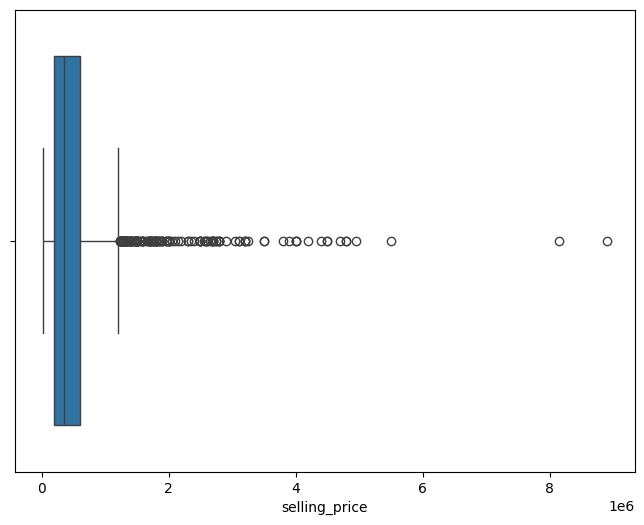

In [19]:
plt.figure(figsize=(8,6))

sns.boxplot(x=data['selling_price'])

plt.show()

In [20]:
Q1 = data['selling_price'].quantile(0.25)

Q3 = data['selling_price'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

data = data[
    (data['selling_price'] >= lower) &
    (data['selling_price'] <= upper)
]

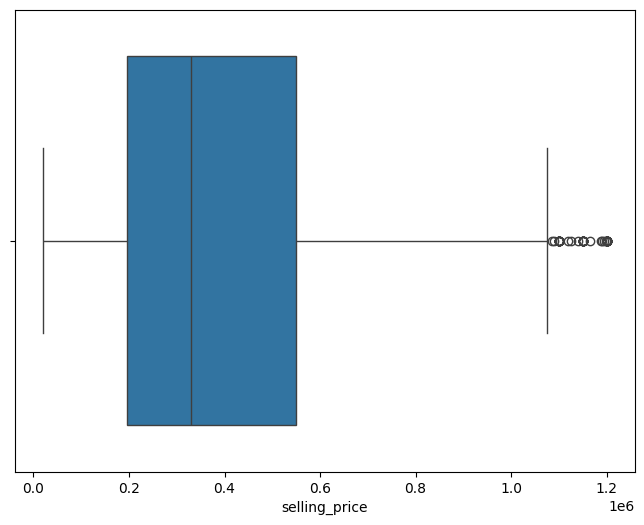

In [21]:
plt.figure(figsize=(8,6))

sns.boxplot(x=data['selling_price'])

plt.show()

In [22]:
le = LabelEncoder()

columns = [
    'fuel',
    'seller_type',
    'transmission',
    'owner'
]

for col in columns:
    data[col] = le.fit_transform(data[col])

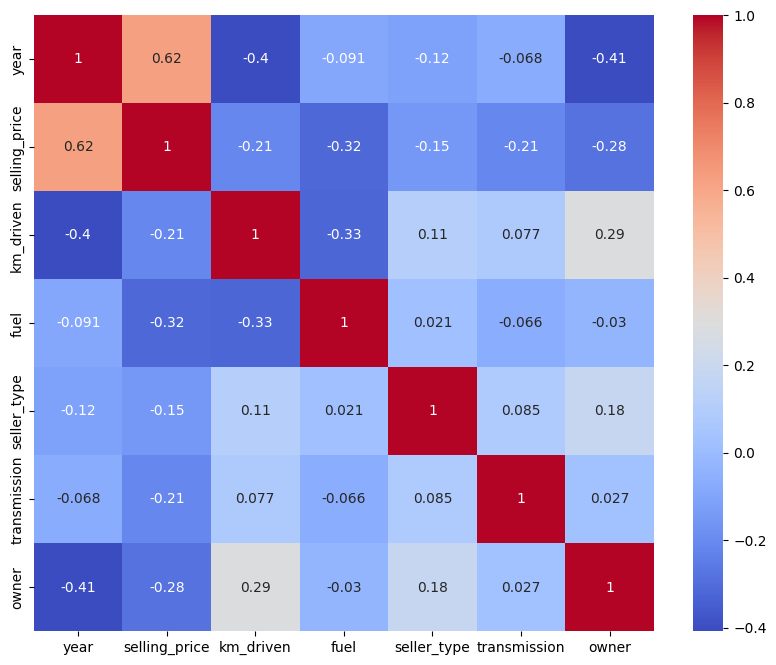

In [23]:
plt.figure(figsize=(10,8))

sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

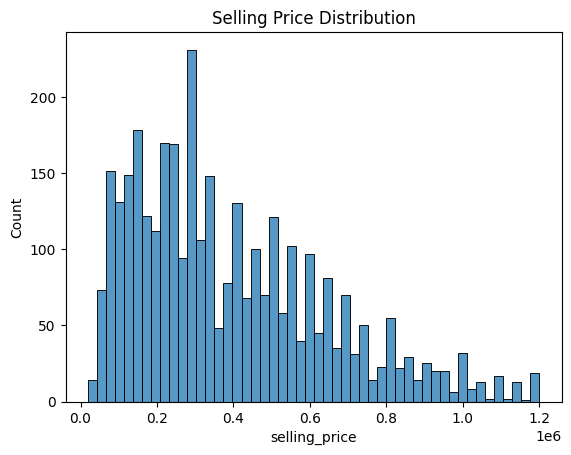

In [24]:
sns.histplot(data['selling_price'], bins=50)

plt.title("Selling Price Distribution")

plt.show()

In [25]:
X = data[
    [
        'year',
        'km_driven',
        'fuel',
        'seller_type',
        'transmission',
        'owner'
    ]
]

y = data['selling_price']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
estimators = [10, 50, 100, 150]

scores = []

for n in estimators:

    model = AdaBoostRegressor(
        n_estimators=n,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    score = r2_score(y_test, y_pred)

    scores.append(score)

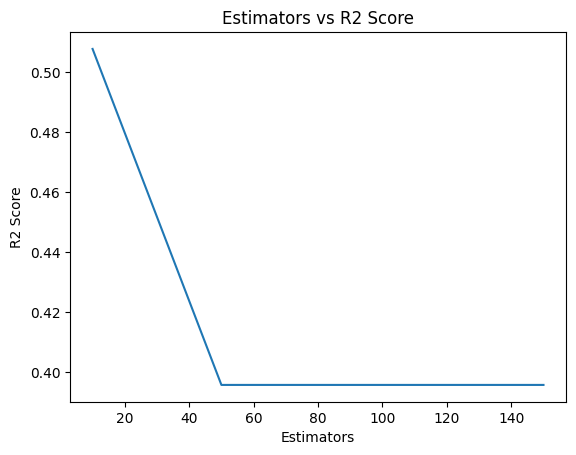

In [28]:
plt.plot(estimators, scores)

plt.xlabel("Estimators")

plt.ylabel("R2 Score")

plt.title("Estimators vs R2 Score")

plt.show()

In [29]:
best_n = estimators[np.argmax(scores)]

print("Best Estimator:", best_n)

Best Estimator: 10


In [30]:
model = AdaBoostRegressor(
    n_estimators=best_n,
    random_state=42
)

model.fit(X_train, y_train)

AdaBoostRegressor(n_estimators=10, random_state=42)

In [31]:
y_pred = model.predict(X_test)

In [32]:
mse = mean_squared_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("MSE:", mse)

print("R2 Score:", r2)

MSE: 30071029934.792706
R2 Score: 0.5077156348693783


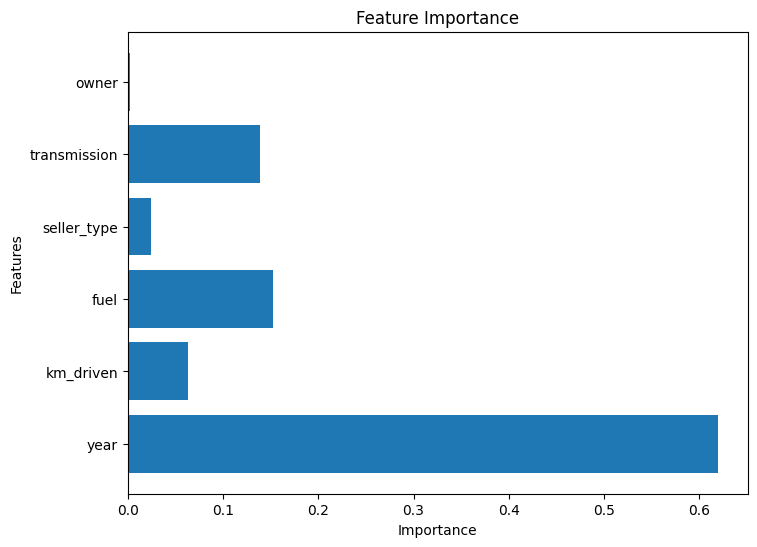

In [33]:
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(8,6))

plt.barh(features, importance)

plt.xlabel("Importance")

plt.ylabel("Features")

plt.title("Feature Importance")

plt.show()

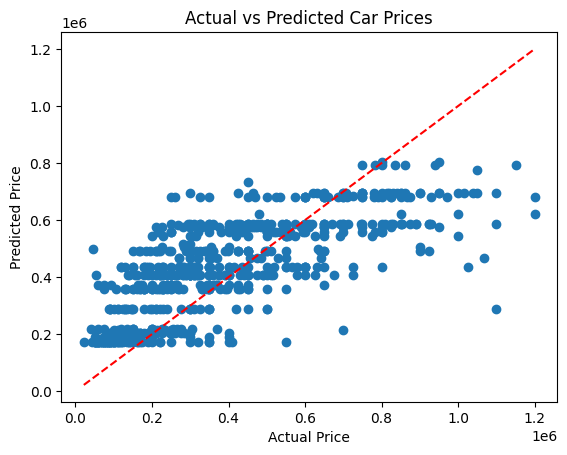

In [34]:
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Car Prices")

plt.show()